# IoT Telemetry Case Study: Ambient Temperature Anomaly Detection

This notebook demonstrates a compact **data processing and anomaly detection** pipeline on an open telemetry time series: the *ambient temperature system failure* dataset from the **Numenta Anomaly Benchmark (NAB)**.

**Dataset URL**: `https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv`

> The dataset contains hourly ambient temperature readings with a known system failure period. We'll load, clean, resample, compute KPIs, and detect anomalies using rolling z-scores and a robust MAD-based method.

## 1. Setup and Imports

In [1]:
# Display plots inline if running in Jupyter
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')


## 2. Load Telemetry Data

We load the time series from the **raw GitHub** URL, parse timestamps, and set a proper DateTimeIndex.

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/numenta/NAB/master/data/realKnownCause/ambient_temperature_system_failure.csv'

# The file has two columns: timestamp,value
tele = pd.read_csv(
    DATA_URL,
    parse_dates=['timestamp']
)
tele = tele.rename(columns={'value': 'ambient_temp_c'})
tele = tele.set_index('timestamp').sort_index()

tele.head()

,ambient_temp_c
timestamp,
2013-07-04 00:00:00,69.880835
2013-07-04 01:00:00,71.220227
2013-07-04 02:00:00,70.877805
2013-07-04 03:00:00,68.959400
2013-07-04 04:00:00,69.283551


### Basic sanity checks

In [3]:
tele.info()

# Summary stats
tele.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7267 entries, 2013-07-04 00:00:00 to 2014-05-28 15:00:00
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ambient_temp_c  7267 non-null   float64
dtypes: float64(1)
memory usage: 113.5 KB


,ambient_temp_c
count,7267.000000
mean,71.242433
std,4.247509
min,57.458406
25%,68.369411
50%,71.858493
75%,74.430958
max,86.223213


## 3. Quality Checks & Missing Values

We check for duplicates, monotonicity, and missing values. Then we create a regularly sampled 1-hour series (original is hourly) and a *denser* 15-minute series to illustrate interpolation.

In [4]:
# Drop duplicate timestamps if any
tele = tele[~tele.index.duplicated(keep='first')]

# Missing values count
missing = tele['ambient_temp_c'].isna().sum()
print(f'Missing raw values: {missing}')

# Regular 1-hour cadence (pad short gaps if present)
tele_1h = tele.resample('1H').mean().interpolate(limit=2)

# Create a 15-minute view to demonstrate resampling/interpolation
tele_15m = tele.resample('15min').mean().interpolate(limit=8)
tele_1h.head(), tele_15m.head()

Missing raw values: 0


C:\Users\gbb919982\AppData\Local\Temp\ipykernel_5972\3423453387.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  tele_1h = tele.resample('1H').mean().interpolate(limit=2)


(                     ambient_temp_c
 timestamp                          
 2013-07-04 00:00:00       69.880835
 2013-07-04 01:00:00       71.220227
 2013-07-04 02:00:00       70.877805
 2013-07-04 03:00:00       68.959400
 2013-07-04 04:00:00       69.283551,
                      ambient_temp_c
 timestamp                          
 2013-07-04 00:00:00       69.880835
 2013-07-04 00:15:00       70.215683
 2013-07-04 00:30:00       70.550531
 2013-07-04 00:45:00       70.885379
 2013-07-04 01:00:00       71.220227)

## 4. Visual Exploration

Plot the ambient temperature time series and its 24-hour rolling mean & standard deviation.

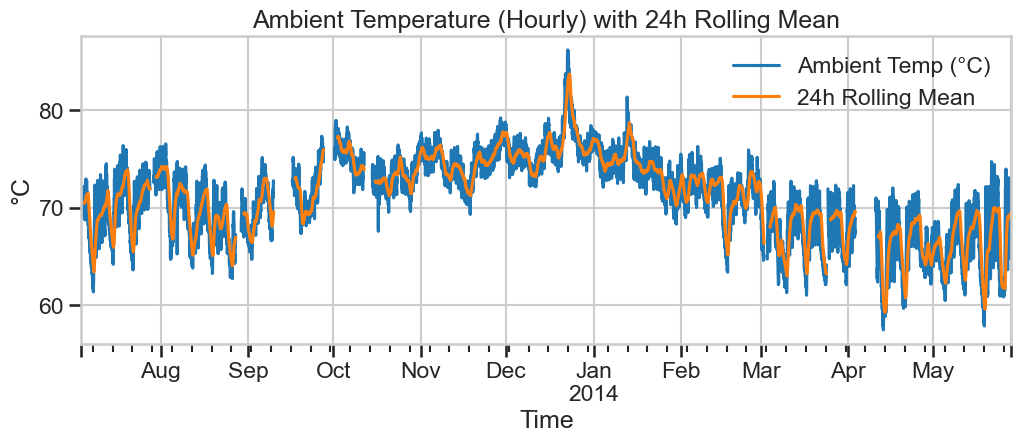

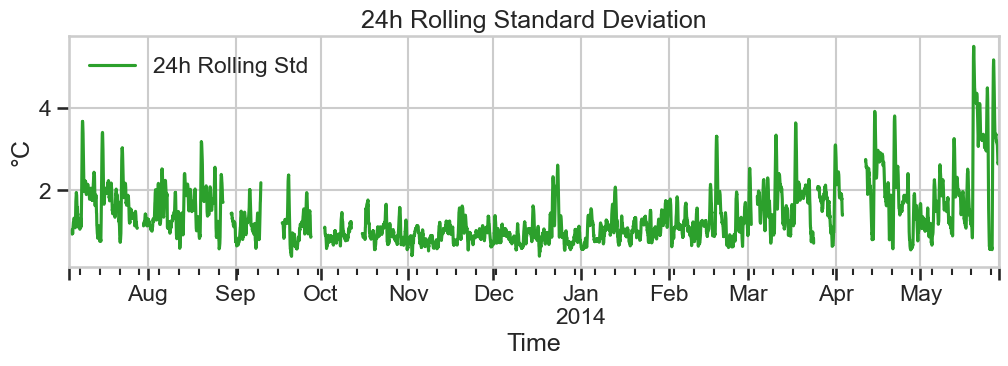

In [5]:
fig, ax = plt.subplots(figsize=(12,4))
tele_1h['ambient_temp_c'].plot(ax=ax, color='tab:blue', label='Ambient Temp (°C)')
tele_1h['ambient_temp_c'].rolling(24).mean().plot(ax=ax, color='tab:orange', label='24h Rolling Mean')
ax.set_title('Ambient Temperature (Hourly) with 24h Rolling Mean')
ax.set_xlabel('Time')
ax.set_ylabel('°C')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(12,3))
tele_1h['ambient_temp_c'].rolling(24).std().plot(ax=ax, color='tab:green', label='24h Rolling Std')
ax.set_title('24h Rolling Standard Deviation')
ax.set_xlabel('Time')
ax.set_ylabel('°C')
ax.legend()
plt.show()

## 5. KPI Computation (Daily)

Compute daily aggregates: mean, p95, min/max. Also count the number of samples per day.

In [6]:
daily = (tele_1h
          .resample('1D')
          .agg(avg_temp=('ambient_temp_c','mean'),
               p95_temp=('ambient_temp_c', lambda x: x.quantile(0.95)),
               tmin=('ambient_temp_c','min'),
               tmax=('ambient_temp_c','max'),
               samples=('ambient_temp_c','count'))
         )

daily.tail()

,avg_temp,p95_temp,tmin,tmax,samples
timestamp,,,,,
2014-05-24,63.616840,68.007829,60.932797,70.530196,24
2014-05-25,61.843362,62.713065,60.847654,62.786565,24
2014-05-26,67.556544,73.379442,61.009384,73.979909,24
2014-05-27,69.006403,72.958773,63.637964,73.087685,24
2014-05-28,68.699634,72.423677,64.784023,72.584089,16


## 6. Anomaly Detection — Rolling Z-Score

We compute a rolling mean/standard deviation over a 24-hour window and flag points with |z| ≥ 3 as anomalies.

In [7]:
window = 24
roll_mean = tele_1h['ambient_temp_c'].rolling(window, min_periods=window//2).mean()
roll_std  = tele_1h['ambient_temp_c'].rolling(window, min_periods=window//2).std()

z = (tele_1h['ambient_temp_c'] - roll_mean) / roll_std
tele_1h['zscore'] = z
tele_1h['z_anomaly'] = z.abs() >= 3

print('Anomaly count (z-score):', int(tele_1h['z_anomaly'].sum()))
tele_1h[['ambient_temp_c','zscore','z_anomaly']].tail()

Anomaly count (z-score): 19


,ambient_temp_c,zscore,z_anomaly
timestamp,,,
2014-05-28 11:00:00,72.370206,1.061955,False
2014-05-28 12:00:00,72.172956,0.988429,False
2014-05-28 13:00:00,72.046565,0.961690,False
2014-05-28 14:00:00,71.825226,0.882226,False
2014-05-28 15:00:00,72.584089,1.152521,False


### Plot z-score anomalies

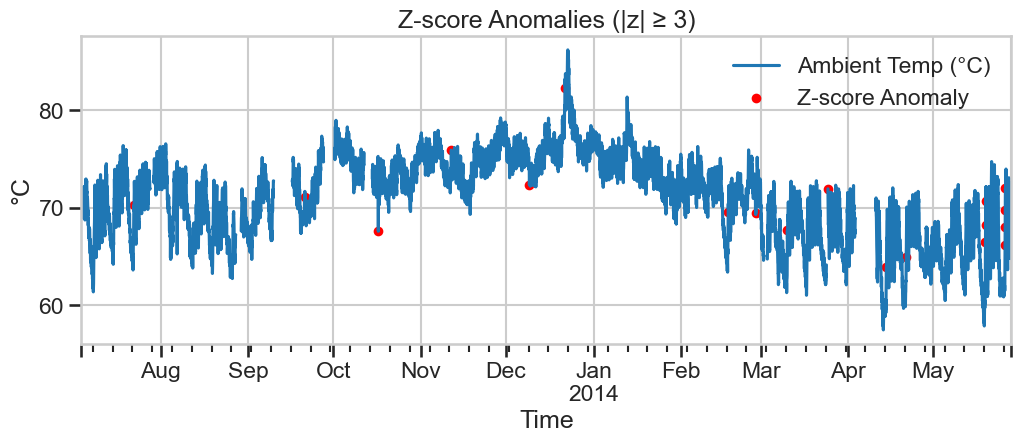

In [8]:
fig, ax = plt.subplots(figsize=(12,4))
series = tele_1h['ambient_temp_c']
series.plot(ax=ax, color='tab:blue', label='Ambient Temp (°C)')
ax.scatter(series.index[tele_1h['z_anomaly']],
           series[tele_1h['z_anomaly']],
           color='red', s=30, label='Z-score Anomaly')
ax.set_title('Z-score Anomalies (|z| ≥ 3)')
ax.set_xlabel('Time')
ax.set_ylabel('°C')
ax.legend()
plt.show()

## 7. Anomaly Detection — Robust (Median + MAD)

Use a robust z-score based on median and **MAD** (Median Absolute Deviation). Points with robust |z| ≥ 3 are flagged.

In [9]:
def mad_based_z(series, window=24):
    med = series.rolling(window, min_periods=window//2).median()
    mad = (series.rolling(window, min_periods=window//2)
                 .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True))
    # Avoid division by zero
    mad = mad.replace(0, np.nan)
    zrob = 0.6745 * (series - med) / mad
    return zrob

tele_1h['robust_z'] = mad_based_z(tele_1h['ambient_temp_c'], window=24)
tele_1h['mad_anomaly'] = tele_1h['robust_z'].abs() >= 3

print('Anomaly count (MAD-based):', int(tele_1h['mad_anomaly'].sum()))
tele_1h[['ambient_temp_c','robust_z','mad_anomaly']].tail()

Anomaly count (MAD-based): 201


,ambient_temp_c,robust_z,mad_anomaly
timestamp,,,
2014-05-28 11:00:00,72.370206,0.769943,False
2014-05-28 12:00:00,72.172956,0.712666,False
2014-05-28 13:00:00,72.046565,0.685986,False
2014-05-28 14:00:00,71.825226,0.621271,False
2014-05-28 15:00:00,72.584089,0.845081,False


### Plot MAD-based anomalies

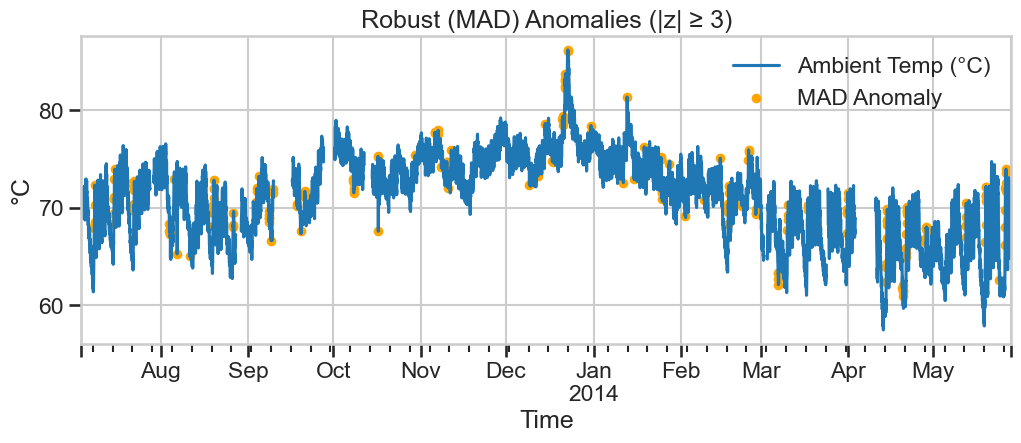

In [10]:
fig, ax = plt.subplots(figsize=(12,4))
series = tele_1h['ambient_temp_c']
series.plot(ax=ax, color='tab:blue', label='Ambient Temp (°C)')
ax.scatter(series.index[tele_1h['mad_anomaly']],
           series[tele_1h['mad_anomaly']],
           color='orange', s=30, label='MAD Anomaly')
ax.set_title('Robust (MAD) Anomalies (|z| ≥ 3)')
ax.set_xlabel('Time')
ax.set_ylabel('°C')
ax.legend()
plt.show()

## 8. Daily Risk Summary

Aggregate anomaly counts per day and join with KPIs to get a compact health/risk table.

In [11]:
anom_daily = (tele_1h
    .assign(temp_anom=lambda d: d['z_anomaly'] | d['mad_anomaly'])
    .resample('1D')['temp_anom']
    .sum()
    .to_frame('anom_count')
)

risk_daily = daily.join(anom_daily, how='left').fillna({'anom_count':0}).astype({'anom_count':'int64'})
risk_daily.tail(10)

,avg_temp,p95_temp,tmin,tmax,samples,anom_count
timestamp,,,,,,
2014-05-19,64.748117,72.010859,57.861906,72.168324,24,9
2014-05-20,66.301074,72.068458,60.885550,72.164153,24,0
2014-05-21,69.057410,74.241188,62.702455,74.745938,24,0
2014-05-22,69.897042,73.596503,63.842891,74.428757,24,0
2014-05-23,69.788346,73.160727,64.564035,73.216487,24,0
2014-05-24,63.616840,68.007829,60.932797,70.530196,24,1
2014-05-25,61.843362,62.713065,60.847654,62.786565,24,0
2014-05-26,67.556544,73.379442,61.009384,73.979909,24,11
2014-05-27,69.006403,72.958773,63.637964,73.087685,24,0


## 9. Export (optional)

Save the detected anomalies and the daily risk table for downstream reporting.

In [12]:
anoms = tele_1h.loc[tele_1h['z_anomaly'] | tele_1h['mad_anomaly'], ['ambient_temp_c','zscore','robust_z']]

anoms.to_csv('telemetry_anomalies.csv', index=True)
risk_daily.to_csv('telemetry_daily_risk.csv', index=True)

print('Saved files: telemetry_anomalies.csv, telemetry_daily_risk.csv')

Saved files: telemetry_anomalies.csv, telemetry_daily_risk.csv


## 10. Next Steps
- Add device metadata (location, device_id) and compute fleet KPIs.
- Use multivariate models (e.g., IsolationForest, Prophet, LSTM Autoencoder) if additional signals exist.
- Automate the pipeline as a scheduled job and publish daily risk dashboards.
